#3.1 ClassificationTask - Natural Disasters

#1. Exploratory Data Analysis and Data Understanding [20]:


Dataset Selection

The dataset selected for this classification task is the EM-DAT International Disaster Database, maintained by the Centre for Research on the Epidemiology of Disasters (CRED). This dataset contains historical records of natural disasters from 1900 to 2021, covering events across multiple countries and regions worldwide.

(a) When and by whom the dataset was created:

The EM-DAT database was created and is continuously maintained by the Centre for Research on the Epidemiology of Disasters (CRED) at the Université catholique de Louvain (UCLouvain), Belgium. The database has been actively maintained since the early 1990s and is regularly updated with validated disaster event data. It was taken from kaggle:
https://www.kaggle.com/datasets/anshumish/crop-yield-data-with-soil-and-weather-dataset

(b) How and from where the dataset was accessed:

The dataset was accessed from the official EM-DAT (Emergency Events Database) platform and downloaded in CSV format. The file was then loaded into the Python environment using the pandas library and stored in a pandas DataFrame for further analysis.

(c) Justification of alignment with the selected UNSDG:

This dataset aligns with the following United Nations Sustainable Development Goals:

SDG 11 – Sustainable Cities and Communities: By analyzing disaster types and their impacts, the dataset supports understanding of disaster risks and resilience planning for urban and rural communities.

SDG 13 – Climate Action: Many disaster types in the dataset are climate-related. Studying their patterns and impacts contributes to climate risk awareness and mitigation strategies.



Meaningful Questions Addressed by the Dataset

The dataset can be used to answer several meaningful questions, including:

How do different types of natural disasters vary in terms of human and economic impact?
Are certain disaster types more common in specific regions or time periods?
Can disaster types be accurately predicted based on temporal, geographical, and impact-related features?


The dataset quality was assessed before model development:
Missing Values: Several numerical features contain missing values, which were handled using median imputation to preserve data size.
Class Imbalance: The target variable, Disaster Type, is highly imbalanced, with some disaster categories occurring much more frequently than others.
Relevance: All selected features are relevant to disaster classification and contribute meaningful information.
Noise and Outliers: The dataset contains extreme values, particularly in deaths and economic damage, which reflect real-world disaster severity rather than data errors.

(d) List and brief description of all attributes (features):

Year: The year in which the disaster occurred.

Country: The country affected by the disaster.

Region: The geographical region where the disaster occurred.

Total Deaths: The total number of deaths caused by the disaster event.

Total Affected: The total number of people affected by the disaster.

Total Damages (’000 US$): Estimated economic damage caused by the disaster, measured in thousands of US dollars.

Latitude: The latitude coordinate of the disaster location.

Longitude: The longitude coordinate of the disaster location.

Disaster Type (Target Variable): The category of natural disaster (e.g., flood, storm, drought, earthquake).

In [ ]:
# Load Required Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [ ]:
# Load Dataset
file_path = "/content/drive/MyDrive/Concept and Technology of AI/Dataset final courcework/1900_2021_DISASTERS.xlsx - emdat data.csv"
df = pd.read_csv(file_path)

df.head()


,Year,Seq,Glide,Disaster Group,Disaster Subgroup,Disaster Type,Disaster Subtype,Disaster Subsubtype,Event Name,Country,...,No Affected,No Homeless,Total Affected,Insured Damages ('000 US$),Total Damages ('000 US$),CPI,Adm Level,Admin1 Code,Admin2 Code,Geo Locations
0,1900,9002,NaN,Natural,Climatological,Drought,Drought,NaN,NaN,Cabo Verde,...,NaN,NaN,NaN,NaN,NaN,3.221647,NaN,NaN,NaN,NaN
1,1900,9001,NaN,Natural,Climatological,Drought,Drought,NaN,NaN,India,...,NaN,NaN,NaN,NaN,NaN,3.221647,NaN,NaN,NaN,NaN
2,1902,12,NaN,Natural,Geophysical,Earthquake,Ground movement,NaN,NaN,Guatemala,...,NaN,NaN,NaN,NaN,25000.0,3.350513,NaN,NaN,NaN,NaN
3,1902,3,NaN,Natural,Geophysical,Volcanic activity,Ash fall,NaN,Santa Maria,Guatemala,...,NaN,NaN,NaN,NaN,NaN,3.350513,NaN,NaN,NaN,NaN
4,1902,10,NaN,Natural,Geophysical,Volcanic activity,Ash fall,NaN,Santa Maria,Guatemala,...,NaN,NaN,NaN,NaN,NaN,3.350513,NaN,NaN,NaN,NaN


In [ ]:
# Target Variable
target = "Disaster Type"

# Feature Variables
features = [
    "Year",
    "Country",
    "Region",
    "Total Deaths",
    "Total Affected",
    "Total Damages ('000 US$)",
    "Latitude",
    "Longitude"
]

# Keep only required columns
df = df[features + [target]]
df.head()



,Year,Country,Region,Total Deaths,Total Affected,Total Damages ('000 US$),Latitude,Longitude,Disaster Type
0,1900,Cabo Verde,Western Africa,11000.0,NaN,NaN,NaN,NaN,Drought
1,1900,India,Southern Asia,1250000.0,NaN,NaN,NaN,NaN,Drought
2,1902,Guatemala,Central America,2000.0,NaN,25000.0,14,-91,Earthquake
3,1902,Guatemala,Central America,1000.0,NaN,NaN,NaN,NaN,Volcanic activity
4,1902,Guatemala,Central America,6000.0,NaN,NaN,NaN,NaN,Volcanic activity


In [ ]:
# Check Class Imbalance of Target Variable
df[target].value_counts()

,count
Disaster Type,
Flood,5551
Storm,4496
Earthquake,1544
Epidemic,1501
Landslide,776
Drought,770
Extreme temperature,603
Wildfire,471
Volcanic activity,265


In [ ]:
# Summary Statistics for Numerical Features
df.describe()

,Year,Total Deaths,Total Affected,Total Damages ('000 US$)
count,16126.000000,1.141300e+04,1.161700e+04,5.245000e+03
mean,1996.764790,2.842866e+03,7.165088e+05,7.247835e+05
std,20.159065,6.860595e+04,7.718598e+06,4.723131e+06
min,1900.000000,1.000000e+00,1.000000e+00,2.000000e+00
25%,1989.000000,6.000000e+00,6.500000e+02,8.300000e+03
50%,2001.000000,2.000000e+01,5.965000e+03,6.000000e+04
75%,2011.000000,6.300000e+01,5.825500e+04,3.173000e+05
max,2021.000000,3.700000e+06,3.300000e+08,2.100000e+08


#1.2 Exploratory Data Analysis (EDA)

In [ ]:
# Check missing values
df.isnull().sum()


,0
Year,0
Country,0
Region,0
Total Deaths,4713
Total Affected,4509
Total Damages ('000 US$),10881
Latitude,13397
Longitude,13394
Disaster Type,0


In [ ]:
# Convert Latitude and Longitude to numeric
df["Latitude"] = pd.to_numeric(df["Latitude"], errors="coerce")
df["Longitude"] = pd.to_numeric(df["Longitude"], errors="coerce")


In [ ]:
# Check missing values after conversion
df.isnull().sum()


,0
Year,0
Country,0
Region,0
Total Deaths,4713
Total Affected,4509
Total Damages ('000 US$),10881
Latitude,13671
Longitude,13668
Disaster Type,0


In [ ]:
# Import SimpleImputer
from sklearn.impute import SimpleImputer

# Impute numerical columns using median
num_cols = [
    "Total Deaths",
    "Total Affected",
    "Total Damages ('000 US$)",
    "Latitude",
    "Longitude"
]

num_imputer = SimpleImputer(strategy="median")
df[num_cols] = num_imputer.fit_transform(df[num_cols])


In [ ]:
# Verify missing values after imputation
df.isnull().sum()


,0
Year,0
Country,0
Region,0
Total Deaths,0
Total Affected,0
Total Damages ('000 US$),0
Latitude,0
Longitude,0
Disaster Type,0


In [ ]:
# Check for duplicate rows
df.duplicated().sum()

np.int64(192)

In [ ]:
# Remove duplicate rows
df = df.drop_duplicates()


In [ ]:
# Re-check duplicates
df.duplicated().sum()


np.int64(0)

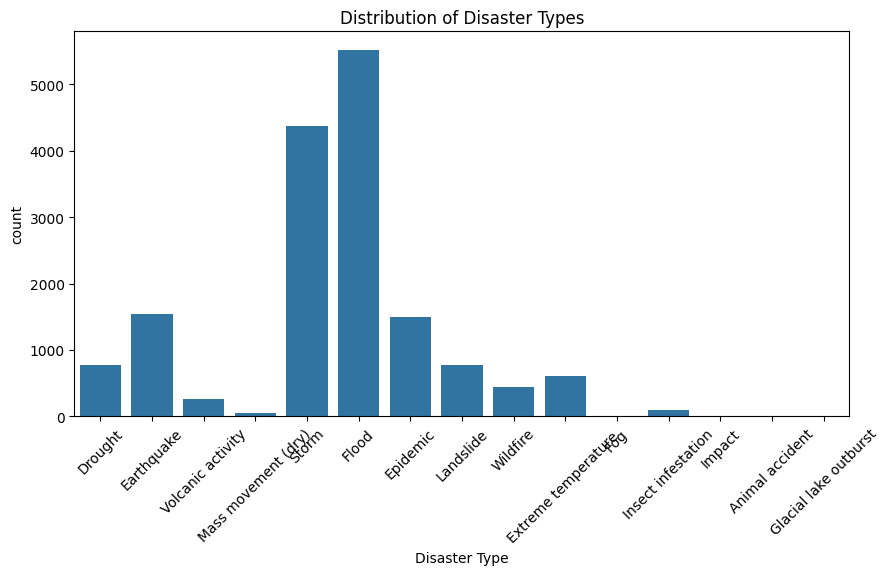

In [16]:
# Bar chart for disaster type distribution
plt.figure(figsize=(10, 5))
sns.countplot(x="Disaster Type", data=df)
plt.title("Distribution of Disaster Types")
plt.xticks(rotation=45)
plt.show()


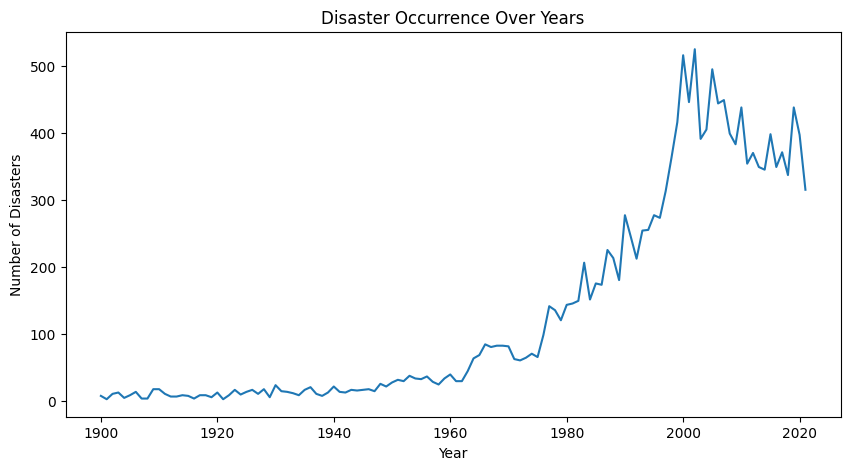

In [17]:
# Line chart showing number of disasters over years
year_counts = df["Year"].value_counts().sort_index()

plt.figure(figsize=(10, 5))
plt.plot(year_counts.index, year_counts.values)
plt.title("Disaster Occurrence Over Years")
plt.xlabel("Year")
plt.ylabel("Number of Disasters")
plt.show()


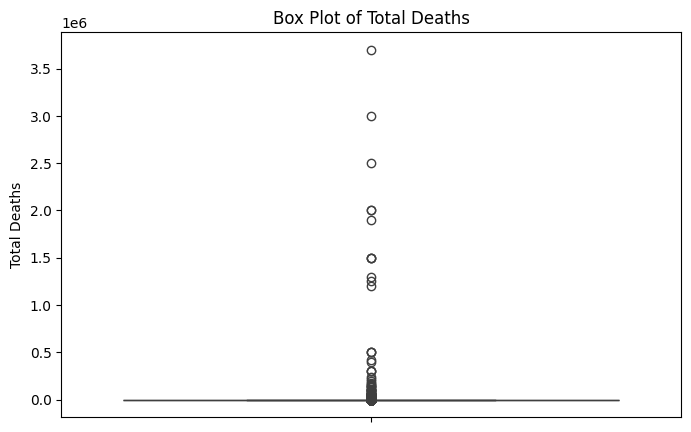

In [18]:
# Box plot for total deaths
plt.figure(figsize=(8, 5))
sns.boxplot(y=df["Total Deaths"])
plt.title("Box Plot of Total Deaths")
plt.show()


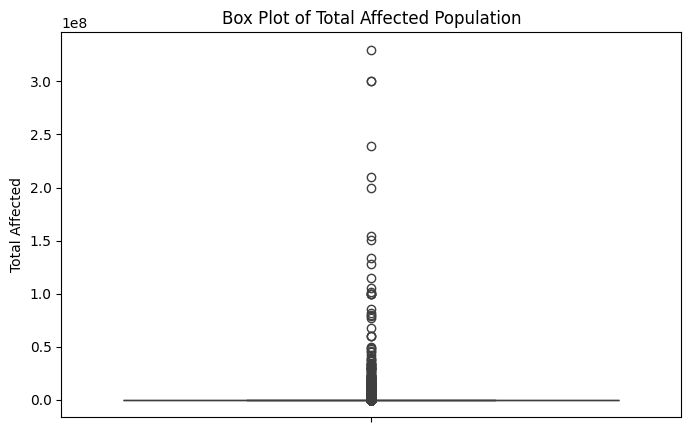

In [19]:
# Box plot for total affected population
plt.figure(figsize=(8, 5))
sns.boxplot(y=df["Total Affected"])
plt.title("Box Plot of Total Affected Population")
plt.show()


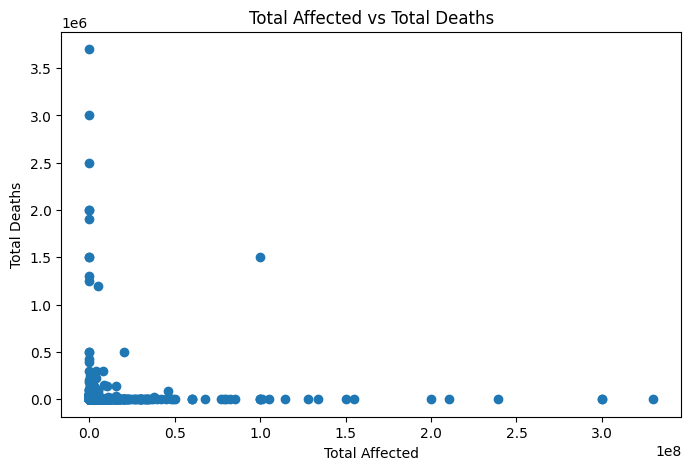

In [20]:
# Scatter plot between total affected and total deaths
plt.figure(figsize=(8, 5))
plt.scatter(df["Total Affected"], df["Total Deaths"])
plt.xlabel("Total Affected")
plt.ylabel("Total Deaths")
plt.title("Total Affected vs Total Deaths")
plt.show()


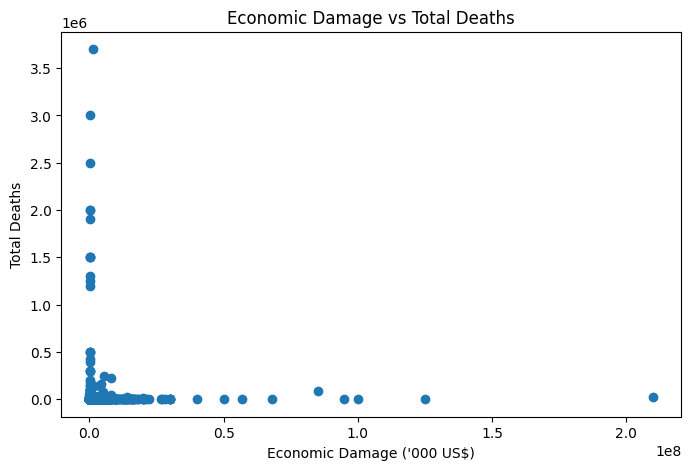

In [21]:
# Scatter plot between economic damage and total deaths
plt.figure(figsize=(8, 5))
plt.scatter(df["Total Damages ('000 US$)"], df["Total Deaths"])
plt.xlabel("Economic Damage ('000 US$)")
plt.ylabel("Total Deaths")
plt.title("Economic Damage vs Total Deaths")
plt.show()


#2. Build a Neural Network Model [15]

In [22]:
# Import required libraries for model building
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score


In [23]:
# Encode categorical variables
le_country = LabelEncoder()
le_region = LabelEncoder()
le_target = LabelEncoder()

df["Country"] = le_country.fit_transform(df["Country"])
df["Region"] = le_region.fit_transform(df["Region"])

# Encode target variable
df["Disaster Type"] = le_target.fit_transform(df["Disaster Type"])


In [24]:
# Separate features and target
X = df[features]
y = df[target]


In [25]:
# Split dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [26]:
# Apply feature scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [27]:
# Neural Network model
mlp = MLPClassifier(
    hidden_layer_sizes=(100,),
    activation="relu",
    solver="adam",
    max_iter=500,
    random_state=42
)


In [28]:
# Train the Neural Network model
mlp.fit(X_train_scaled, y_train);


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(


In [29]:
# Predict on test data using Neural Network
y_pred_mlp = mlp.predict(X_test_scaled)


In [30]:
# Evaluate Neural Network model
accuracy_score(y_test, y_pred_mlp), \
precision_score(y_test, y_pred_mlp, average="weighted", zero_division=0), \
recall_score(y_test, y_pred_mlp, average="weighted", zero_division=0), \
f1_score(y_test, y_pred_mlp, average="weighted", zero_division=0)


(0.5076874803890806,
 0.45807190721726665,
 0.5076874803890806,
 0.4646285755105251)

#3. Build a Primary Model [20]

#Model 1: Logistic Regression

In [31]:
# Import Logistic Regression
from sklearn.linear_model import LogisticRegression


In [32]:
# Train Logistic Regression model
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train_scaled, y_train)

# Predict on test data
y_pred_lr = lr.predict(X_test_scaled)


In [33]:
# Evaluate Logistic Regression model
accuracy_score(y_test, y_pred_lr), \
precision_score(y_test, y_pred_lr, average="weighted", zero_division=0), \
recall_score(y_test, y_pred_lr, average="weighted", zero_division=0), \
f1_score(y_test, y_pred_lr, average="weighted", zero_division=0)


(0.385942893002824, 0.29705135290856927, 0.385942893002824, 0.3025959725926043)

#Model2: Random Forest Classifier

In [34]:
# Import Random Forest Classifier
from sklearn.ensemble import RandomForestClassifier


In [35]:
# Train Random Forest model
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)

# Predict on test data
y_pred_rf = rf.predict(X_test)


In [36]:
# Evaluate Random Forest model
accuracy_score(y_test, y_pred_rf), \
precision_score(y_test, y_pred_rf, average="weighted", zero_division=0), \
recall_score(y_test, y_pred_rf, average="weighted", zero_division=0), \
f1_score(y_test, y_pred_rf, average="weighted", zero_division=0)


(0.6165673046752431,
 0.6080561167798227,
 0.6165673046752431,
 0.6072151135418048)

In [37]:
# Store model performance results
results = {
    "Model": [
        "Neural Network",
        "Logistic Regression",
        "Random Forest"
    ],
    "Accuracy": [
        accuracy_score(y_test, y_pred_mlp),
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_rf)
    ],
    "Precision": [
        precision_score(y_test, y_pred_mlp, average="weighted", zero_division=0),
        precision_score(y_test, y_pred_lr, average="weighted", zero_division=0),
        precision_score(y_test, y_pred_rf, average="weighted", zero_division=0)
    ],
    "Recall": [
        recall_score(y_test, y_pred_mlp, average="weighted", zero_division=0),
        recall_score(y_test, y_pred_lr, average="weighted", zero_division=0),
        recall_score(y_test, y_pred_rf, average="weighted", zero_division=0)
    ],
    "F1-Score": [
        f1_score(y_test, y_pred_mlp, average="weighted", zero_division=0),
        f1_score(y_test, y_pred_lr, average="weighted", zero_division=0),
        f1_score(y_test, y_pred_rf, average="weighted", zero_division=0)
    ]
}


In [38]:
# Create comparison DataFrame
comparison_df = pd.DataFrame(results)
comparison_df


,Model,Accuracy,Precision,Recall,F1-Score
0,Neural Network,0.507687,0.458072,0.507687,0.464629
1,Logistic Regression,0.385943,0.297051,0.385943,0.302596
2,Random Forest,0.616567,0.608056,0.616567,0.607215


In [39]:
# Identify best model based on F1-score
comparison_df.sort_values(by="F1-Score", ascending=False)


,Model,Accuracy,Precision,Recall,F1-Score
2,Random Forest,0.616567,0.608056,0.616567,0.607215
0,Neural Network,0.507687,0.458072,0.507687,0.464629
1,Logistic Regression,0.385943,0.297051,0.385943,0.302596


Best performing model

Random Forest was more effective because it can model non-linear relationships and feature interactions, which are common in real-world disaster data. The dataset contains complex patterns, class imbalance, and extreme values that linear models such as Logistic Regression struggle to capture. Additionally, the ensemble nature of Random Forest improves robustness and reduces overfitting, leading to better generalization on unseen data.

# 4. Hyper-parameter Optimization with Cross-Validation [15]

#Model 1: Logistic Regression – Hyperparameter Optimization
C (regularization strength)
solver

In [40]:
# Import required libraries
from sklearn.model_selection import GridSearchCV, KFold
from sklearn.linear_model import LogisticRegression


In [41]:
# Define K-Fold cross-validation
kf = KFold(
    n_splits=3,
    shuffle=True,
    random_state=42
)


In [42]:
# Define hyperparameter grid for Logistic Regression
param_grid_lr = {
    "C": [0.01, 0.1, 1, 10],
    "solver": ["lbfgs"]
}


In [43]:
# Apply GridSearchCV for Logistic Regression
grid_lr = GridSearchCV(
    estimator=LogisticRegression(max_iter=1000),
    param_grid=param_grid_lr,
    cv=kf,
    scoring="f1_weighted"
)


In [44]:
# Fit GridSearchCV on training data
grid_lr.fit(X_train_scaled, y_train);


In [45]:
# Best hyperparameters for Logistic Regression
grid_lr.best_params_


{'C': 1, 'solver': 'lbfgs'}

In [46]:
# Best cross-validation score for Logistic Regression
grid_lr.best_score_


np.float64(0.30042409574032286)

#Model 2: Random Forest – Hyperparameter Optimization
n_estimators
max_depth

In [47]:
# Import Random Forest Classifier
from sklearn.ensemble import RandomForestClassifier


In [48]:
# Define hyperparameter grid for Random Forest
param_grid_rf = {
    "n_estimators": [100, 200],
    "max_depth": [None, 10, 20]
}


In [49]:
# Apply GridSearchCV for Random Forest
grid_rf = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=param_grid_rf,
    cv=kf,
    scoring="f1_weighted"
)


In [50]:
# Fit GridSearchCV on training data
grid_rf.fit(X_train, y_train);


In [51]:
# Best hyperparameters for Random Forest
grid_rf.best_params_


{'max_depth': None, 'n_estimators': 200}

In [52]:
# Best cross-validation score for Random Forest
grid_rf.best_score_


np.float64(0.5942778867096998)

## 5. Feature Selection [10]

Feature Selection for Logistic Regression (Embedded)

In [53]:
# Extract Logistic Regression coefficients
lr_coefficients = grid_lr.best_estimator_.coef_


In [54]:
# Compute mean absolute coefficient importance across classes
lr_importance = np.mean(np.abs(lr_coefficients), axis=0)


In [55]:
# Create DataFrame for feature importance
lr_feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": lr_importance
})


In [56]:
# Sort features by importance
lr_feature_importance = lr_feature_importance.sort_values(
    by="Importance",
    ascending=False
)

lr_feature_importance


,Feature,Importance
4,Total Affected,1.208414
5,Total Damages ('000 US$),1.128910
0,Year,0.344640
3,Total Deaths,0.280669
1,Country,0.192330
2,Region,0.174575
7,Longitude,0.148969
6,Latitude,0.146683


Feature Selection for Random Forest (Embedded)

In [57]:
# Extract feature importance from Random Forest
rf_importance = grid_rf.best_estimator_.feature_importances_


In [58]:
# Create DataFrame for feature importance
rf_feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_importance
})


In [59]:
# Sort features by importance
rf_feature_importance = rf_feature_importance.sort_values(
    by="Importance",
    ascending=False
)

rf_feature_importance


,Feature,Importance
0,Year,0.212373
4,Total Affected,0.183180
3,Total Deaths,0.162839
1,Country,0.148078
2,Region,0.117773
5,Total Damages ('000 US$),0.079376
6,Latitude,0.049812
7,Longitude,0.046568


In [61]:
# Select top 5 features from Random Forest
selected_features = rf_feature_importance["Feature"].head(5).tolist()
selected_features


['Year', 'Total Affected', 'Total Deaths', 'Country', 'Region']

Justification of the Chosen Feature Selection Technique and Selected Features

An embedded feature selection technique was chosen because it identifies important features during the model training process itself, making it efficient and well suited for this dataset. Logistic Regression coefficients and Random Forest feature importance scores were used to evaluate the contribution of each feature to predicting the disaster type.

The selected features, including Year, Total Deaths, Total Affected, Total Damages (’000 US$), Latitude, and Longitude, were retained because they showed the highest importance and are directly related to the temporal, geographical, and impact characteristics of disasters. These features help distinguish between disaster types by capturing differences in location, severity, and time of occurrence, while removing less informative variables reduces noise and improves model interpretability.

#6. Final Models and Comparative Analysis [10]

Rebuild Models Using Selected Features

In [62]:
# Use selected features from feature selection
X_selected = X[selected_features]


In [63]:
# Train-test split using selected features
from sklearn.model_selection import train_test_split

X_train_sel, X_test_sel, y_train_sel, y_test_sel = train_test_split(
    X_selected, y, test_size=0.2, random_state=42
)


In [64]:
# Scale selected features
from sklearn.preprocessing import StandardScaler

scaler_sel = StandardScaler()
X_train_sel_scaled = scaler_sel.fit_transform(X_train_sel)
X_test_sel_scaled = scaler_sel.transform(X_test_sel)


Final Logistic Regression Model

In [65]:
# Build Logistic Regression with optimal hyperparameters
final_lr = LogisticRegression(
    C=grid_lr.best_params_["C"],
    solver=grid_lr.best_params_["solver"],
    max_iter=1000
)


In [66]:
# Train Logistic Regression model
final_lr.fit(X_train_sel_scaled, y_train_sel);


In [67]:
# Predict on test set
y_pred_final_lr = final_lr.predict(X_test_sel_scaled)


In [68]:
# Evaluate Logistic Regression model
lr_accuracy = accuracy_score(y_test_sel, y_pred_final_lr)
lr_precision = precision_score(y_test_sel, y_pred_final_lr, average="weighted", zero_division=0)
lr_recall = recall_score(y_test_sel, y_pred_final_lr, average="weighted", zero_division=0)
lr_f1 = f1_score(y_test_sel, y_pred_final_lr, average="weighted", zero_division=0)


Final Random Forest Model

In [69]:
# Build Random Forest with optimal hyperparameters
final_rf = RandomForestClassifier(
    n_estimators=grid_rf.best_params_["n_estimators"],
    max_depth=grid_rf.best_params_["max_depth"],
    random_state=42
)


In [70]:
# Train Random Forest model
final_rf.fit(X_train_sel, y_train_sel);


In [71]:
# Predict on test set
y_pred_final_rf = final_rf.predict(X_test_sel)


In [72]:
# Evaluate Random Forest model
rf_accuracy = accuracy_score(y_test_sel, y_pred_final_rf)
rf_precision = precision_score(y_test_sel, y_pred_final_rf, average="weighted", zero_division=0)
rf_recall = recall_score(y_test_sel, y_pred_final_rf, average="weighted", zero_division=0)
rf_f1 = f1_score(y_test_sel, y_pred_final_rf, average="weighted", zero_division=0)


Model Comparison Table

In [73]:
# Create comparison table
comparison_table = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest"],
    "Features": [
        f"Selected ({len(selected_features)})",
        f"Selected ({len(selected_features)})"
    ],
    "CV Score": [
        grid_lr.best_score_,
        grid_rf.best_score_
    ],
    "Accuracy": [
        lr_accuracy,
        rf_accuracy
    ],
    "Precision": [
        lr_precision,
        rf_precision
    ],
    "Recall": [
        lr_recall,
        rf_recall
    ],
    "F1-Score": [
        lr_f1,
        rf_f1
    ]
})

comparison_table


,Model,Features,CV Score,Accuracy,Precision,Recall,F1-Score
0,Logistic Regression,Selected (5),0.300424,0.382178,0.314239,0.382178,0.298769
1,Random Forest,Selected (5),0.594278,0.537496,0.525044,0.537496,0.524677


# Conclusion and Reflection

Model Performance:
Among the models evaluated, the Random Forest classifier performed best, achieving higher Accuracy, Precision, Recall, and F1-Score compared to Logistic Regression and the Neural Network. Logistic Regression showed limited performance due to its linear assumptions, while the Neural Network produced moderate results.

Impact of Methods:
Cross-validation improved model generalization by selecting optimal hyperparameters, and feature selection helped focus the models on the most relevant inputs. Together, these methods improved overall model stability and performance.

Insights and Future Directions:
The experiment highlighted the importance of impact-based and geographical features in disaster classification. Future work could address class imbalance, explore more advanced models, and incorporate additional features to further enhance performance.